## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

Lexinejazly Asuncion, lexinejazly.asuncion@sjsu.edu, SJSU ID: 017077242

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv"
drinks = pd.read_csv(url)

drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


In [11]:
drinks.drop("total_litres_of_pure_alcohol", axis=1, inplace=True)

tidy_drinks = drinks.melt(
    id_vars="country",
    var_name="drink",
    value_name="servings")

tidy_drinks.head()

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [12]:
tidy_drinks['drink'] = tidy_drinks['drink'].str.replace('_servings', '', regex=False)
tidy_drinks.head()

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_beer = tidy_drinks[tidy_drinks["drink"] == "beer"].nlargest(10, "servings")
top_10_wine = tidy_drinks[tidy_drinks["drink"] == "wine"].nlargest(10, "servings")
top_10_spirits = tidy_drinks[tidy_drinks["drink"] == "spirit"].nlargest(10, "servings")

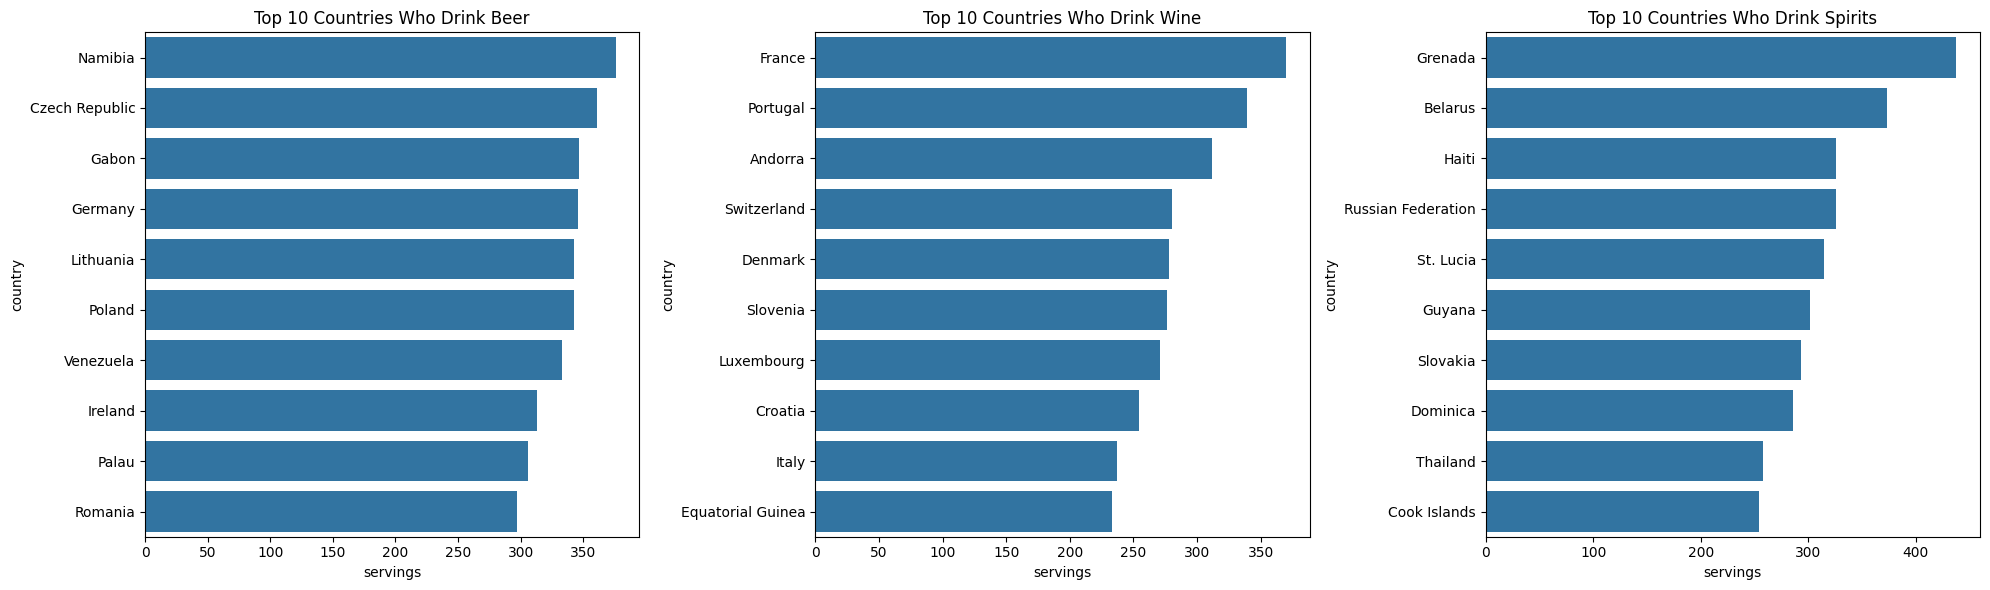

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=top_10_beer,
            x="servings",
            y="country",
            ax=axes[0])
axes[0].set_title('Top 10 Countries Who Drink Beer')

sns.barplot(data=top_10_wine,
            x="servings",
            y="country",
            ax=axes[1])
axes[1].set_title('Top 10 Countries Who Drink Wine')

sns.barplot(data=top_10_spirits,
            x="servings",
            y="country",
            ax=axes[2])
axes[2].set_title('Top 10 Countries Who Drink Spirits')

plt.tight_layout()
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [18]:
wide_drinks = tidy_drinks.pivot_table(index='country',
                                      columns='drink',
                                      values='servings')

wide_drinks = wide_drinks.reset_index()
wide_drinks.columns.name = None

wide_drinks.head()

,country,beer,spirit,wine
0,Afghanistan,0.0,0.0,0.0
1,Albania,89.0,132.0,54.0
2,Algeria,25.0,0.0,14.0
3,Andorra,245.0,138.0,312.0
4,Angola,217.0,57.0,45.0
